In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os

In [2]:
import getObsAtmo
from getObsAtmo.getObsAtmo import ObsAtmo,validateObsName,Dict_Of_sitesPressures,_getPackageDir,get_obssite_dataframe,get_obssite_keys,is_obssite

In [3]:
outdir = './emulated_transparencies/'
if os.path.exists(outdir)==False:
    os.mkdir(outdir)

In [4]:
Dict_Of_sitesPressures

{'LSST': 731.50433,
 'CTIO': 774.6052,
 'OHP': 937.22595,
 'ZTF': 823.60004,
 'VLT': 734.08038,
 'PDM': 710.90637,
 'OMK': 600.17224,
 'OSL': 1013.0}

In [5]:
obssitename = 'AuxTel'
obs_str = validateObsName(obssitename) 
pressure = Dict_Of_sitesPressures[obs_str]
print(pressure)

731.50433


In [6]:
emul1 =  ObsAtmo(obs_str= obssitename)

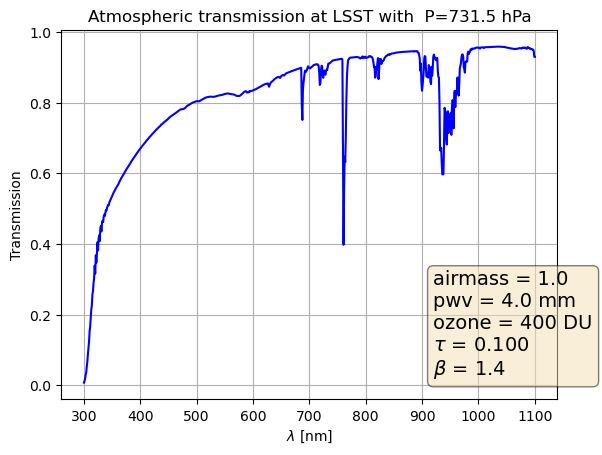

In [7]:
emul1.plot_transmission()

In [8]:
WL = emul1.GetWL()

In [19]:
atm_params = ['pwv','tau','oz','am','p']

atm_ranges = {'pwv_min':1.0,'pwv_max':9.0,'pwv_std':3.0,
              'tau_min':0.01,'tau_max':0.09,'tau_std':0.04,
              'oz_min':200,'oz_max':400,'oz_std':300,
              'am_min':1.0,'am_max':2.5,'am_std':1.2,
              'p_min':0.9*pressure,'p_max':1.1*pressure,'p_std':pressure,
}


## Select variable atm parameter

In [20]:
var_param = 'p'
fix_params = {}
for param_ in atm_params:
    if param_!=var_param:
        fix_params[param_] = atm_ranges['{0}_std'.format(param_)]
fix_params

{'pwv': 3.0, 'tau': 0.04, 'oz': 300, 'am': 1.2}

In [21]:
n_sim = 9

var_range = np.linspace(atm_ranges['{0}_min'.format(var_param)],atm_ranges['{0}_max'.format(var_param)],n_sim)
var_range

array([658.353897  , 676.64150525, 694.9291135 , 713.21672175,
       731.50433   , 749.79193825, 768.0795465 , 786.36715475,
       804.654763  ])

In [24]:
def eval_GetAllTransparencies(fix_params,var_param,param_range):
    results = {}
    if var_param!='p':
        for val_ in param_range:
            kwargs = fix_params.copy()
            kwargs[var_param] = val_
            results[val_] = emul1.GetAllTransparencies(WL,**kwargs)
    else:
        for val_ in param_range:
            emul_ = ObsAtmo(obs_str= obssitename,pressure = val_)
            kwargs = fix_params.copy()
            results[val_] = emul_.GetAllTransparencies(WL,**kwargs)
    return results

In [25]:
sims = eval_GetAllTransparencies(fix_params,var_param,var_range)
transm_ref = emul1.GetAllTransparencies(WL,atm_ranges['am_std'],atm_ranges['pwv_std'],atm_ranges['oz_std'],atm_ranges['tau_std'])

658.353897
676.6415052499999
694.9291135
713.21672175
731.50433
749.7919382499999
768.0795465
786.36715475
804.654763


Text(0.5, 1.0, 'Varying p')

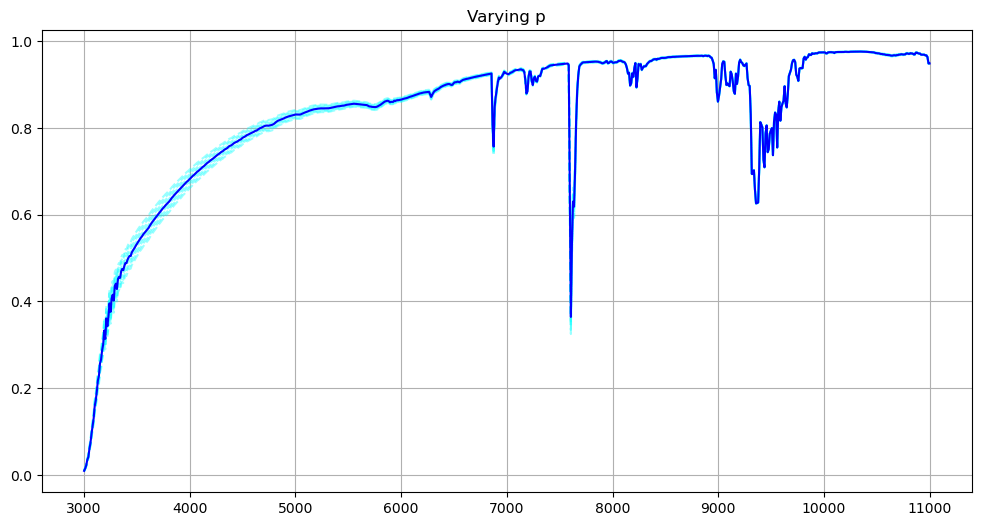

In [26]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)

ls_ = '--'
color_ = 'cyan'
for sim_val in sims.keys():
    print(sim_val)
    transm_ = sims[sim_val]
    ax.plot(WL*10.,transm_,ls=ls_,color=color_,alpha=0.4)
ax.plot(WL*10,transm_ref,ls='-',color='b',alpha=1.0)
ax.grid()
ax.set_title('Varying {0}'.format(var_param))

In [27]:
outfile = 'emulated_transparencies_var_param_{0}.npy'.format(var_param)

output_dict = {'wl':WL}
for sim_val in var_range:
    output_dict['{0}_{1}'.format(var_param,sim_val)] = sims[sim_val]
output_dict['{0}_ref_{1}'.format(var_param,atm_ranges['{0}_std'.format(var_param)])] = transm_ref

In [28]:
output_dict.keys()

dict_keys(['wl', 'p_658.353897', 'p_676.6415052499999', 'p_694.9291135', 'p_713.21672175', 'p_731.50433', 'p_749.7919382499999', 'p_768.0795465', 'p_786.36715475', 'p_804.654763', 'p_ref_731.50433'])

In [29]:
np.save(os.path.join(outdir,outfile),output_dict)